## Ensemble β-VAE
Trains `n_ensemble` VAEs with different random seeds to assess sensitivity of reconstruction skill/latent embedding space

> **0729 update:** Analyses 2 and 3 now align every ensemble member to the actual
> paper reference run (March 6, seed=1, test-set-only, dated) instead of to
> ensemble Run 01. The reference run is external to the ensemble -- all 50
> members are aligned to it, none are skipped/treated as the reference anymore.

In [2]:
# import packages
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from numpy import genfromtxt
import os
from scipy.optimize import linear_sum_assignment

# for vae
# need keras version 2.15.0
import keras
from keras.layers import Input, Dense, Lambda
from keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers

2026-08-01 13:57:28.039280: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-01 13:57:28.658382: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 13:57:28.658425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 13:57:28.659734: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-01 13:57:28.694323: I tensorflow/core/platform/cpu_feature_guar

## Data

scaled and sequential inputs

In [3]:
scaled_input_ohc_train = genfromtxt('ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test  = genfromtxt('ohc700_test_robustscaler.csv',  delimiter=',')

scaled_input_sst_train = genfromtxt('sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test  = genfromtxt('sst_test_robustscaler.csv',  delimiter=',')

scaled_input_olr_train = genfromtxt('olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test  = genfromtxt('olr_test_robustscaler.csv',  delimiter=',')

In [4]:
# load netcdf files with time component
sequential_input_ohc_train = xr.load_dataarray('ohc700_train_robustscaler.nc')
sequential_input_ohc_test  = xr.load_dataarray('ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('olr_train_robustscaler.nc')
sequential_input_olr_test  = xr.load_dataarray('olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('sst_train_robustscaler.nc')
sequential_input_sst_test  = xr.load_dataarray('sst_test_robustscaler.nc')

In [5]:
# sanity checks
print(scaled_input_sst_train.shape,
      scaled_input_sst_test.shape,
      scaled_input_ohc_train.shape,
      scaled_input_ohc_test.shape,
      scaled_input_olr_train.shape,
      scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


## Model configuration

In [6]:
# input shapes
input_shape_sst = scaled_input_sst_train.shape[1]
input_shape_ohc = scaled_input_ohc_train.shape[1]
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_sst, input_shape_ohc, input_shape_olr)

# latent dimensionality
latent_dim = 20

# ensemble size (using 50 for this analysis)
n_ensemble = 50

# output directory to preserve runs
run_dir = 'ensemble_runs_v2'
os.makedirs(run_dir, exist_ok=True)

2968 2960 2662


## Build VAE function

more streamlined beta-VAE construction, easier to call for each ensemble run

In [7]:
# reparameterization trick — defined outside build_vae so Lambda can pickle it
def sampling(args):
    z_mean, z_log_var = args
    epsilon = keras.backend.random_normal(
        shape=keras.backend.shape(z_mean), mean=0., stddev=1.
    )
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon


class VAELossLayer(layers.Layer):
    """Custom loss layer that tracks per-variable MSE and KL divergence separately."""

    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr,
                 kl_weight=0.0005, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        (input_sst, input_ohc, input_olr,
         output_sst, output_ohc, output_olr,
         z_mean, z_log_var) = inputs

        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)

        self.add_metric(reconstruction_loss_sst, name='sst_loss', aggregation='mean')
        self.add_metric(reconstruction_loss_ohc, name='ohc_loss', aggregation='mean')
        self.add_metric(reconstruction_loss_olr, name='olr_loss', aggregation='mean')

        reconstruction_loss = (reconstruction_loss_sst
                                + reconstruction_loss_ohc
                                + reconstruction_loss_olr)

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5 * self.kl_weight

        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name='kl_loss', aggregation='mean')

        return (output_sst, output_ohc, output_olr,
                total_loss, kl_loss,
                reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr)


def build_vae(input_shape_sst, input_shape_ohc, input_shape_olr,
              latent_dim=20, kl_weight=0.0005):
    """Construct and compile β-VAE model, returns (vae, encoder)."""

    # encoder construction
    input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
    x = Dense(400, activation='tanh')(input_sst)
    x = Dense(250, activation='tanh')(x)
    x = Dense(180, activation='tanh')(x)
    x = Dense(100, activation='tanh')(x)
    encoded_sst = Dense(30, activation='tanh')(x)

    input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
    x = Dense(400, activation='tanh')(input_ohc)
    x = Dense(250, activation='tanh')(x)
    x = Dense(180, activation='tanh')(x)
    x = Dense(100, activation='tanh')(x)
    encoded_ohc = Dense(30, activation='tanh')(x)

    input_olr = Input(shape=(np.int64(input_shape_olr),), name='input_olr')
    x = Dense(400, activation='tanh')(input_olr)
    x = Dense(250, activation='tanh')(x)
    x = Dense(180, activation='tanh')(x)
    x = Dense(100, activation='tanh')(x)
    encoded_olr = Dense(30, activation='tanh')(x)

    # latent space
    concat = keras.layers.Concatenate()([encoded_sst, encoded_ohc, encoded_olr])
    z_mean    = Dense(latent_dim, name='z_mean')(concat)
    z_log_var = Dense(latent_dim, name='z_log_var')(concat)
    z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

    # decoder construction
    def decode_branch(z, output_dim, name):
        x = Dense(30,  activation='tanh')(z)
        x = Dense(100, activation='tanh')(x)
        x = Dense(180, activation='tanh')(x)
        x = Dense(250, activation='tanh')(x)
        x = Dense(400, activation='tanh')(x)
        return Dense(np.int64(output_dim), activation='linear', name=name)(x)

    output_sst = decode_branch(z, input_shape_sst, 'output_sst')
    output_ohc = decode_branch(z, input_shape_ohc, 'output_ohc')
    output_olr = decode_branch(z, input_shape_olr, 'output_olr')

    # custom loss layer
    outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr,
                           kl_weight=kl_weight)(
        [input_sst, input_ohc, input_olr,
         output_sst, output_ohc, output_olr,
         z_mean, z_log_var]
    )

    vae = keras.Model(
        inputs=[input_sst, input_ohc, input_olr],
        outputs=outputs
    )
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003),
                run_eagerly=True)

    # separate encoder model to extract latent embeddings after training
    encoder = keras.Model(
        inputs=[input_sst, input_ohc, input_olr],
        outputs=[z_mean, z_log_var, z]
    )

    return vae, encoder

## Ensemble training loop

Each run uses a different random seed. Latent embeddings on the test set (1200) are saved to disk after each run (for crash recovery)

In [8]:
ensemble_z_means   = []
ensemble_z_stds    = []
ensemble_histories = []
ensemble_rmse      = []
ensemble_mae       = []

for run in range(n_ensemble):
    z_mean_path   = f'{run_dir}/z_mean_run{run:02d}.npy'
    z_std_path    = f'{run_dir}/z_std_run{run:02d}.npy'
    metrics_path  = f'{run_dir}/metrics_run{run:02d}.npy'  # [rmse_sst, rmse_ohc, rmse_olr, mae_sst, mae_ohc, mae_olr]
    weights_path  = f'{run_dir}/vae_weights_run{run:02d}.weights.h5'

    if (os.path.exists(z_mean_path) and os.path.exists(z_std_path)
            and os.path.exists(metrics_path) and os.path.exists(weights_path)):
        print(f'Run {run+1}/{n_ensemble} — loading from cache')
        ensemble_z_means.append(np.load(z_mean_path))
        ensemble_z_stds.append(np.load(z_std_path))
        metrics = np.load(metrics_path)
        ensemble_rmse.append(metrics[:3])
        ensemble_mae.append(metrics[3:])
        continue

    keras.utils.set_random_seed(run)
    tf.random.set_seed(run)

    vae, encoder = build_vae(input_shape_sst, input_shape_ohc, input_shape_olr,
                             latent_dim=latent_dim)

    history = vae.fit(
        x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
        y=None,
        epochs=150,
        batch_size=256,
        validation_split=0.25,
        verbose=0
    )
    ensemble_histories.append(history)

    # save full VAE weights for later per-run ablation analysis
    vae.save_weights(weights_path)

    # latent embeddings on test set — grab z_mean and z_log_var
    z_mean_i, z_log_var_i, _ = encoder.predict(
        [scaled_input_sst_test, scaled_input_ohc_test, scaled_input_olr_test],
        verbose=0
    )
    z_std_i = np.exp(0.5 * z_log_var_i)

    ensemble_z_means.append(z_mean_i)
    ensemble_z_stds.append(z_std_i)
    np.save(z_mean_path, z_mean_i)
    np.save(z_std_path,  z_std_i)

    # reconstruction metrics on test set
    preds = vae.predict(
        [scaled_input_sst_test, scaled_input_ohc_test, scaled_input_olr_test],
        verbose=0
    )
    pred_sst, pred_ohc, pred_olr = preds[0], preds[1], preds[2]

    rmse_sst = np.sqrt(np.mean((scaled_input_sst_test - pred_sst) ** 2))
    rmse_ohc = np.sqrt(np.mean((scaled_input_ohc_test - pred_ohc) ** 2))
    rmse_olr = np.sqrt(np.mean((scaled_input_olr_test - pred_olr) ** 2))
    mae_sst  = np.mean(np.abs(scaled_input_sst_test - pred_sst))
    mae_ohc  = np.mean(np.abs(scaled_input_ohc_test - pred_ohc))
    mae_olr  = np.mean(np.abs(scaled_input_olr_test - pred_olr))

    ensemble_rmse.append([rmse_sst, rmse_ohc, rmse_olr])
    ensemble_mae.append([mae_sst,  mae_ohc,  mae_olr])
    np.save(metrics_path, np.array([rmse_sst, rmse_ohc, rmse_olr,
                                    mae_sst,  mae_ohc,  mae_olr]))

    print(f'Run {run+1:2d}/{n_ensemble} | '
          f'RMSE SST={rmse_sst:.4f}  OHC={rmse_ohc:.4f}  OLR={rmse_olr:.4f}')

ensemble_z_means = np.array(ensemble_z_means)  # (n_ensemble, n_test, latent_dim)
ensemble_z_stds  = np.array(ensemble_z_stds)   # (n_ensemble, n_test, latent_dim)
ensemble_rmse    = np.array(ensemble_rmse)      # (n_ensemble, 3)
ensemble_mae     = np.array(ensemble_mae)       # (n_ensemble, 3)
print('\nEnsemble training complete.')

Run 1/50 — loading from cache
Run 2/50 — loading from cache
Run 3/50 — loading from cache
Run 4/50 — loading from cache
Run 5/50 — loading from cache
Run 6/50 — loading from cache
Run 7/50 — loading from cache
Run 8/50 — loading from cache
Run 9/50 — loading from cache
Run 10/50 — loading from cache
Run 11/50 — loading from cache
Run 12/50 — loading from cache
Run 13/50 — loading from cache
Run 14/50 — loading from cache
Run 15/50 — loading from cache
Run 16/50 — loading from cache
Run 17/50 — loading from cache
Run 18/50 — loading from cache
Run 19/50 — loading from cache
Run 20/50 — loading from cache
Run 21/50 — loading from cache
Run 22/50 — loading from cache
Run 23/50 — loading from cache
Run 24/50 — loading from cache
Run 25/50 — loading from cache
Run 26/50 — loading from cache
Run 27/50 — loading from cache
Run 28/50 — loading from cache
Run 29/50 — loading from cache
Run 30/50 — loading from cache
Run 31/50 — loading from cache
Run 32/50 — loading from cache
Run 33/50 — loadi

In [9]:
# sanity check for outputs
print(ensemble_z_means.shape,
      ensemble_z_stds.shape,
      ensemble_rmse.shape,  
      ensemble_mae.shape)

(50, 1200, 20) (50, 1200, 20) (50, 3) (50, 3)


## Analysis 1: Reconstruction error spread

In [10]:
variables = ['SST', 'OHC', 'OLR']

# print summary stats
print('RMSE mean ± std across ensemble:')
for j, v in enumerate(variables):
    print(f'  {v}: {ensemble_rmse[:, j].mean():.3f} ± {ensemble_rmse[:, j].std():.3f}')

print('MAE mean ± std across ensemble:')
for j, v in enumerate(variables):
    print(f'  {v}: {ensemble_mae[:, j].mean():.3f} ± {ensemble_mae[:, j].std():.3f}')

RMSE mean ± std across ensemble:
  SST: 0.398 ± 0.004
  OHC: 0.390 ± 0.004
  OLR: 0.632 ± 0.004
MAE mean ± std across ensemble:
  SST: 0.305 ± 0.003
  OHC: 0.296 ± 0.003
  OLR: 0.460 ± 0.003


## Analysis 2: Latent space reproducibility

How consistent is the latent embedding space across runs, relative to the paper's
reference run (March 6, seed=1)? The reference run is external to the 50-member
ensemble -- it is not one of the `ensemble_z_means` runs, so no run is
skipped/excluded here anymore (previously Run 01 served as the in-ensemble
reference and was excluded from its own alignment loop).

In [11]:
# Verify the .csv (used to build ensemble_z_means) and .nc (used to date the
# reference run's TESTONLY file) test sets are in the same row order before
# using them together for correlation-based alignment. If this ever comes back
# False, STOP -- the alignment below would silently compare mismatched samples.
csv_vs_nc_match = np.allclose(scaled_input_sst_test, sequential_input_sst_test.values, atol=1e-5)
print(f"CSV and NC test rows match, same order: {csv_vs_nc_match}")
#assert csv_vs_nc_match, "CSV/NC test row order mismatch -- do not proceed with alignment.

CSV and NC test rows match, same order: True


In [12]:
# reference run = the actual paper reference run (March 6, seed=1), external
# to the ensemble -- loaded from the test-set-only, dated file (see the
# variance_tests notebook's "reference run analysis" section for how this
# was recovered/verified).
_ds_ref_main = xr.open_dataset('latent_representations_zmean_TESTONLY.nc')
ref = _ds_ref_main['z_mean'].values  # (1200, 20)

assert ref.shape == ensemble_z_means[0].shape, (
    f"Reference shape {ref.shape} != ensemble member shape {ensemble_z_means[0].shape}"
)

aligned_corrs = []  # sign-invariant correlation (optimally matched dim)
perm_indices  = []  # permutation mapping each run's dims to the reference dims
run_indices   = list(range(n_ensemble))  # ALL 50 runs -- none excluded, since the
                                          # reference is no longer one of them

for i in run_indices:
    z = ensemble_z_means[i]
    # build absolute correlation matrix
    # absolute value accounts for sign indeterminacy across runs (inherent to vaes)
    corr_matrix = np.zeros((latent_dim, latent_dim))
    for d_ref in range(latent_dim):
        for d_run in range(latent_dim):
            corr_matrix[d_ref, d_run] = np.abs(
                np.corrcoef(ref[:, d_ref], z[:, d_run])[0, 1]
            )

    # find one-to-one assignment of run dimensions to reference dimensions
    # that maximizes total absolute correlation (optimal permutation matching)
    row_ind, col_ind = linear_sum_assignment(-corr_matrix)
    aligned_corrs.append(corr_matrix[row_ind, col_ind])
    perm_indices.append(col_ind)

aligned_corrs = np.array(aligned_corrs)  # (n_ensemble, latent_dim)

print('Mean absolute correlation per latent dimension after optimal alignment to the reference run')
print('(higher = more reproducible across runs):')
for d in range(latent_dim):
    print(f'  dim {d+1:2d}: {aligned_corrs[:, d].mean():.3f} ± {aligned_corrs[:, d].std():.3f}')

Mean absolute correlation per latent dimension after optimal alignment to the reference run
(higher = more reproducible across runs):
  dim  1: 0.650 ± 0.106
  dim  2: 0.527 ± 0.115
  dim  3: 0.473 ± 0.131
  dim  4: 0.438 ± 0.123
  dim  5: 0.439 ± 0.135
  dim  6: 0.577 ± 0.121
  dim  7: 0.435 ± 0.133
  dim  8: 0.545 ± 0.119
  dim  9: 0.521 ± 0.110
  dim 10: 0.487 ± 0.111
  dim 11: 0.488 ± 0.129
  dim 12: 0.611 ± 0.124
  dim 13: 0.458 ± 0.118
  dim 14: 0.499 ± 0.141
  dim 15: 0.556 ± 0.109
  dim 16: 0.468 ± 0.121
  dim 17: 0.639 ± 0.120
  dim 18: 0.476 ± 0.111
  dim 19: 0.473 ± 0.121
  dim 20: 0.565 ± 0.114


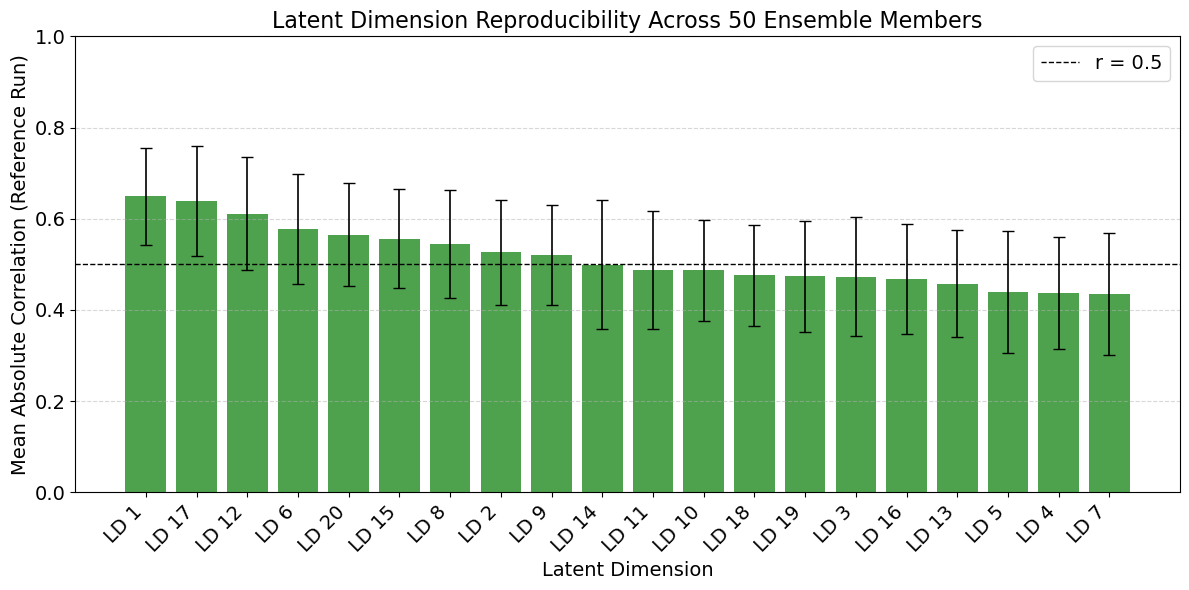

In [13]:
# sort dimensions in descending order of correlation for plot
mean_corr = aligned_corrs.mean(axis=0)
std_corr  = aligned_corrs.std(axis=0)
sort_idx  = np.argsort(mean_corr)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(latent_dim)
ax.bar(x, mean_corr[sort_idx], yerr=std_corr[sort_idx],
       capsize=4, color='forestgreen', alpha=0.8, error_kw=dict(elinewidth=1.2))
ax.set_xticks(x)
ax.set_xticklabels([f'LD {sort_idx[i]+1}' for i in x], rotation=45, ha='right', fontsize=14)
ax.set_ylabel('Mean Absolute Correlation (Reference Run)', fontsize=14)
ax.set_xlabel('Latent Dimension', fontsize=14)
ax.set_title(f'Latent Dimension Reproducibility Across 50 Ensemble Members', fontsize=16)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='r = 0.5')
ax.legend(fontsize=14)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('ensemble_reproducibility_0801.pdf', bbox_inches='tight')
plt.show()

## Analysis 3: Ensemble mean and std latent embedding

Align every run to the external reference run (March 6, seed=1) from Analysis 2,
then compute the mean and standard deviation of each test sample's latent
coordinate across ensemble members. Save out netcdf file for future use.

In [14]:
# align every ensemble run to the EXTERNAL reference run
# (no "reference run unchanged" special case anymore -- the reference isn't
# one of the 50 ensemble members, so all 50 get permuted/sign-corrected)
aligned_z_means = [None] * n_ensemble

for i, perm in zip(run_indices, perm_indices):
    z = ensemble_z_means[i]
    z_aligned = z[:, perm].copy()  # reorder dimensions to match reference
    # correct sign flips: same reference used for the permutation above
    for d in range(latent_dim):
        if np.corrcoef(ref[:, d], z_aligned[:, d])[0, 1] < 0:
            z_aligned[:, d] *= -1
    aligned_z_means[i] = z_aligned

aligned_z_means = np.array(aligned_z_means)  # (n_ensemble, n_test, latent_dim)

# mean and std across ensemble members, per sample, per dimension
z_ensemble_mean = aligned_z_means.mean(axis=0)  # (n_test, latent_dim)
z_ensemble_std  = aligned_z_means.std(axis=0)   # (n_test, latent_dim)

print(f'z_ensemble_mean shape: {z_ensemble_mean.shape}')
print(f'z_ensemble_std  shape: {z_ensemble_std.shape}')

z_ensemble_mean shape: (1200, 20)
z_ensemble_std  shape: (1200, 20)


In [16]:
# run this cell last!
time_coords = sequential_input_sst_test.time.values

ds_out = xr.Dataset(
    {
        'z_mean': xr.DataArray(z_ensemble_mean, dims=['time', 'latent_dim'],
                               coords={'time': time_coords,
                                       'latent_dim': np.arange(1, latent_dim + 1)}),
        'z_std':  xr.DataArray(z_ensemble_std,  dims=['time', 'latent_dim'],
                               coords={'time': time_coords,
                                       'latent_dim': np.arange(1, latent_dim + 1)}),
    },
    attrs={
        'description': (
            'Ensemble mean/std latent representations, 50 members, each aligned '
            'via optimal permutation matching to the external paper reference run '
            '(March 6, seed=1, test-set-only) rather than to ensemble Run 01.'
        ),
    },
)
ds_out.to_netcdf('latent_representations_ensemble_mean_0729.nc')
print('Saved ensemble mean and std latent representations.')

Saved ensemble mean and std latent representations.
